In [1]:
import cv2
from matplotlib import pyplot as plt
from pathlib import Path
import torch
import numpy as np
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)


import sys
sys.path.append('..')

import src.ModelTrain as ModelTrain


In [2]:
F1_FIG_NAME = 'f1_score_evolution.png'
LOSS_FIG_NAME = 'loss_evolution.png'
CONF_MATRIX_NAME = 'confusion_matrix.png'

In [3]:
train1 = ModelTrain.TrainingConfig(    
    train_ratio=0.8,
    random_state=42,

    input_size=224,
    val_resize_size=256,
    batch_size=32,
    num_workers=0,
    num_epochs=100,

    warmup_epochs=3,
    trainable_backbone_blocks=3,
    enable_backbone_finetuning=True,
    full_network_finetuning=True,

    head_lr=1e-3,
    fine_tune_head_lr=1e-4,
    backbone_lr=1e-5,

    weight_decay=5e-4,
    dropout=0.3,
    stochastic_depth_prob=0.1,
    label_smoothing=0.02,

    scheduler_factor=0.5,
    scheduler_patience=4,
    early_stopping_patience=12,
    min_lr=1e-6,
    gradient_clip_norm=1.0,

    use_weighted_loss=True,
    use_weighted_sampler=False,
    class_weight_exponent= 0.5
)

Cargando modelo guardado desde: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1_05\best_baseline_model.pth


C:\Users\luis\AppData\Local\Temp\ipykernel_19756\1694246138.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(best_model_weights_path, map_location=device)


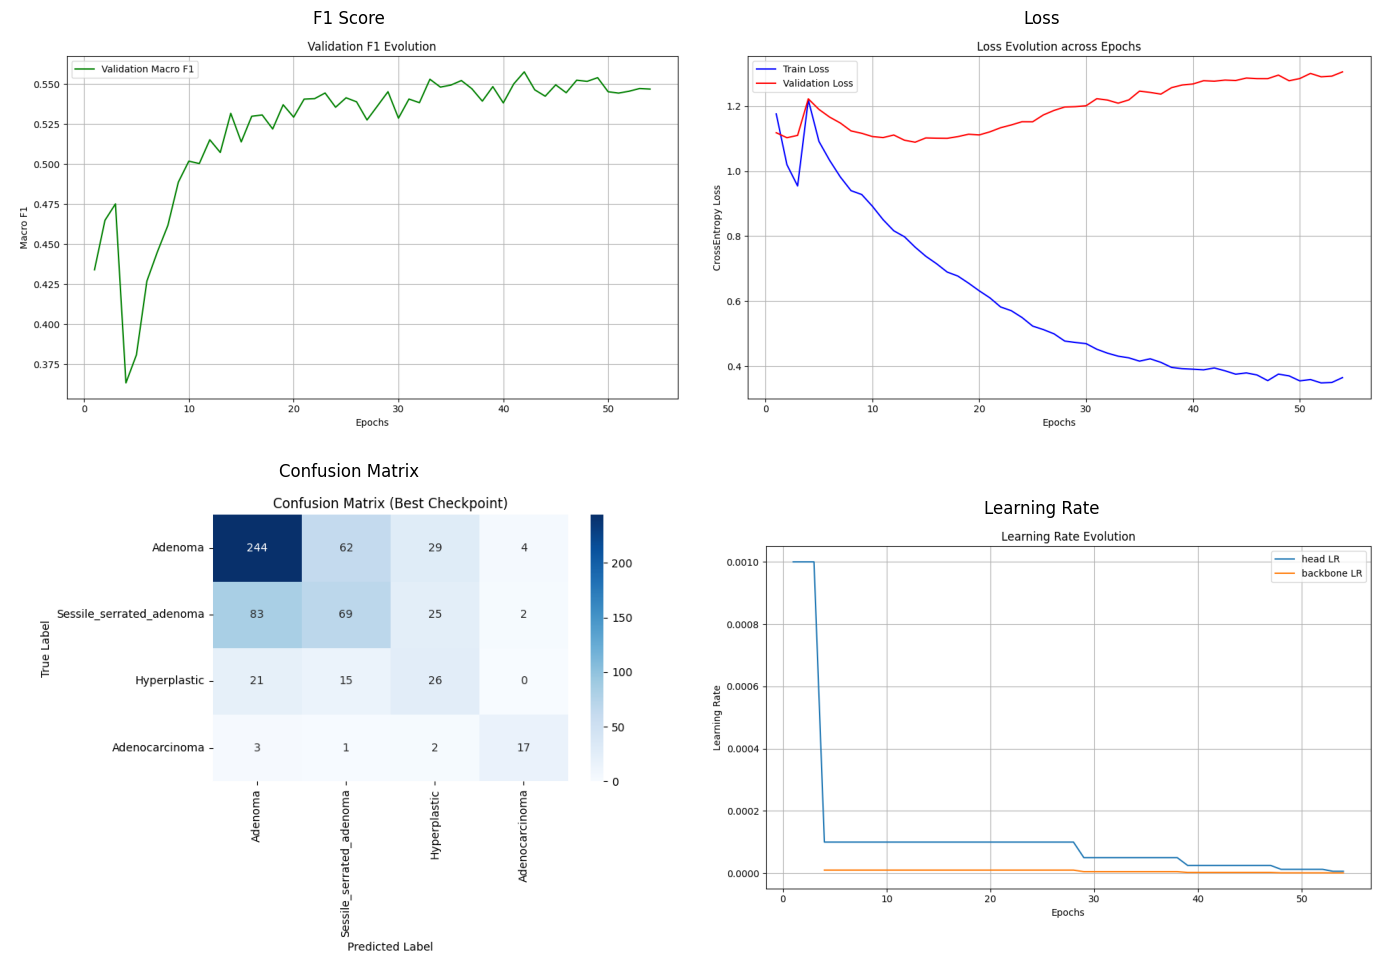

=== GLOBAL METRICS ===
Accuracy:          0.5904
Balanced Accuracy: 0.5659
Macro F1:          0.5577
Weighted F1:       0.5886

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.6952    0.7198    0.7072       339
Sessile_serrated_adenoma     0.4694    0.3855    0.4233       179
            Hyperplastic     0.3171    0.4194    0.3611        62
          Adenocarcinoma     0.7391    0.7391    0.7391        23

                accuracy                         0.5904       603
               macro avg     0.5552    0.5659    0.5577       603
            weighted avg     0.5909    0.5904    0.5886       603



In [4]:
baseline_img_dir = Path("unified_images")
baseline_csv_dir = Path("unified_data_baseline.csv")
results_dir = Path("baseline_experiment1_05")

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
best_model_weights_path = results_path / "best_baseline_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not results_path.exists() or not best_model_weights_path.exists():
    trained_model, validation_loader = ModelTrain.train(
        baseline_csv_dir,
        baseline_img_dir,
        results_dir,
        train1,
    )
else:
    print(f"Cargando modelo guardado desde: {best_model_weights_path}")
    trained_model = ModelTrain.PolypClassifier(
        num_classes=len(ModelTrain.CLASS_NAMES),
        dropout=train1.dropout,
        stochastic_depth_prob=train1.stochastic_depth_prob,
    ).to(device)
    trained_model.load_state_dict(
        torch.load(best_model_weights_path, map_location=device)
    )
    trained_model.eval()

    metadata_path = ModelTrain.DATA_DIR / baseline_csv_dir
    train_metadata_df, val_metadata_df = ModelTrain.perform_clinical_data_split(
        metadata_path,
        train_ratio=train1.train_ratio,
        random_state=train1.random_state,
    )
    train_dataset, val_dataset = ModelTrain.build_datasets(
        train_metadata_df,
        val_metadata_df,
        images_dir=ModelTrain.DATA_DIR / baseline_img_dir,
        config=train1,
    )
    _, validation_loader = ModelTrain.build_dataloaders(
        train_dataset,
        val_dataset,
        train_metadata_df=train_metadata_df,
        config=train1,
        device=device,
    )


image_paths = [
    results_path / "f1_score_evolution.png",
    results_path / "loss_evolution.png",
    results_path / "confusion_matrix.png",
    results_path / "learning_rate_evolution.png",
]

titles = [
    "F1 Score",
    "Loss",
    "Confusion Matrix",
    "Learning Rate",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, img_path, title in zip(axes, image_paths, titles):
    img = cv2.imread(str(img_path))

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(
            0.5, 0.5,
            f"Error: {img_path.name} not found",
            fontsize=12,
            color="red",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


device = next(trained_model.parameters()).device
trained_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in validation_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ModelTrain.CLASS_NAMES

accuracy = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("=== GLOBAL METRICS ===")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")


print("\n=== PER-CLASS METRICS ===")
report_text = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report_text)

Cargando modelo guardado desde: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1_1\best_baseline_model.pth


C:\Users\luis\AppData\Local\Temp\ipykernel_19756\273641378.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(best_model_weights_path, map_location=device)


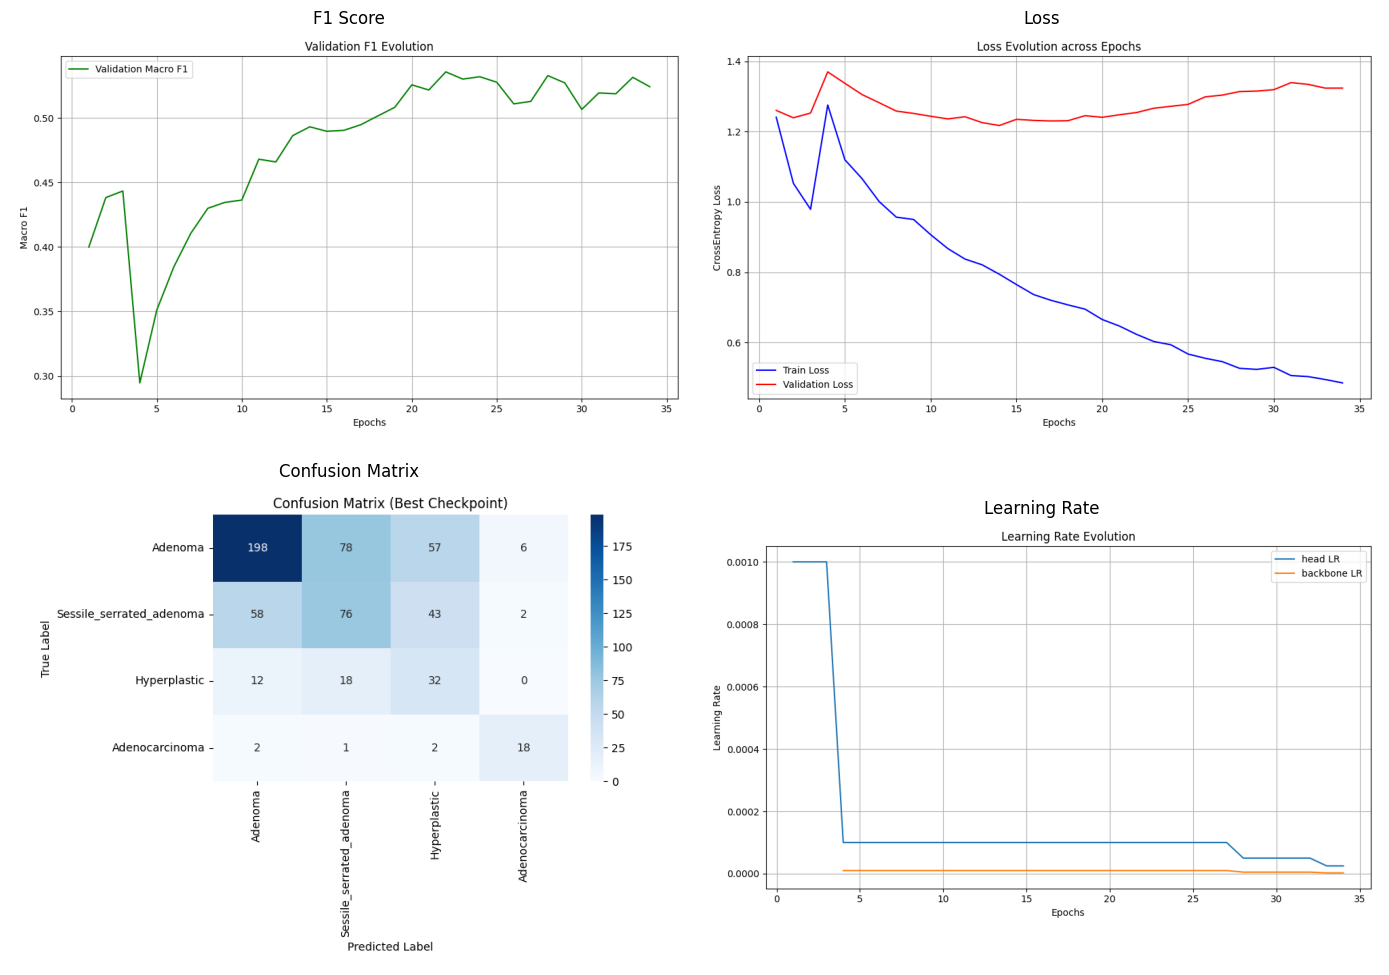

=== GLOBAL METRICS ===
Accuracy:          0.5373
Balanced Accuracy: 0.5768
Macro F1:          0.5358
Weighted F1:       0.5553

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.7333    0.5841    0.6502       339
Sessile_serrated_adenoma     0.4393    0.4246    0.4318       179
            Hyperplastic     0.2388    0.5161    0.3265        62
          Adenocarcinoma     0.6923    0.7826    0.7347        23

                accuracy                         0.5373       603
               macro avg     0.5259    0.5768    0.5358       603
            weighted avg     0.5936    0.5373    0.5553       603



In [5]:
train1.class_weight_exponent = 1.0

baseline_img_dir = Path("unified_images")
baseline_csv_dir = Path("unified_data_baseline.csv")
results_dir = Path("baseline_experiment1_1")

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
best_model_weights_path = results_path / "best_baseline_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not results_path.exists() or not best_model_weights_path.exists():
    trained_model, validation_loader = ModelTrain.train(
        baseline_csv_dir,
        baseline_img_dir,
        results_dir,
        train1,
    )
else:
    print(f"Cargando modelo guardado desde: {best_model_weights_path}")
    trained_model = ModelTrain.PolypClassifier(
        num_classes=len(ModelTrain.CLASS_NAMES),
        dropout=train1.dropout,
        stochastic_depth_prob=train1.stochastic_depth_prob,
    ).to(device)
    trained_model.load_state_dict(
        torch.load(best_model_weights_path, map_location=device)
    )
    trained_model.eval()

    metadata_path = ModelTrain.DATA_DIR / baseline_csv_dir
    train_metadata_df, val_metadata_df = ModelTrain.perform_clinical_data_split(
        metadata_path,
        train_ratio=train1.train_ratio,
        random_state=train1.random_state,
    )
    train_dataset, val_dataset = ModelTrain.build_datasets(
        train_metadata_df,
        val_metadata_df,
        images_dir=ModelTrain.DATA_DIR / baseline_img_dir,
        config=train1,
    )
    _, validation_loader = ModelTrain.build_dataloaders(
        train_dataset,
        val_dataset,
        train_metadata_df=train_metadata_df,
        config=train1,
        device=device,
    )


image_paths = [
    results_path / "f1_score_evolution.png",
    results_path / "loss_evolution.png",
    results_path / "confusion_matrix.png",
    results_path / "learning_rate_evolution.png",
]

titles = [
    "F1 Score",
    "Loss",
    "Confusion Matrix",
    "Learning Rate",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, img_path, title in zip(axes, image_paths, titles):
    img = cv2.imread(str(img_path))

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(
            0.5, 0.5,
            f"Error: {img_path.name} not found",
            fontsize=12,
            color="red",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


device = next(trained_model.parameters()).device
trained_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in validation_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ModelTrain.CLASS_NAMES

accuracy = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("=== GLOBAL METRICS ===")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")


print("\n=== PER-CLASS METRICS ===")
report_text = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report_text)

Cargando modelo guardado desde: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1_2\best_baseline_model.pth


C:\Users\luis\AppData\Local\Temp\ipykernel_19756\1297648762.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(best_model_weights_path, map_location=device)


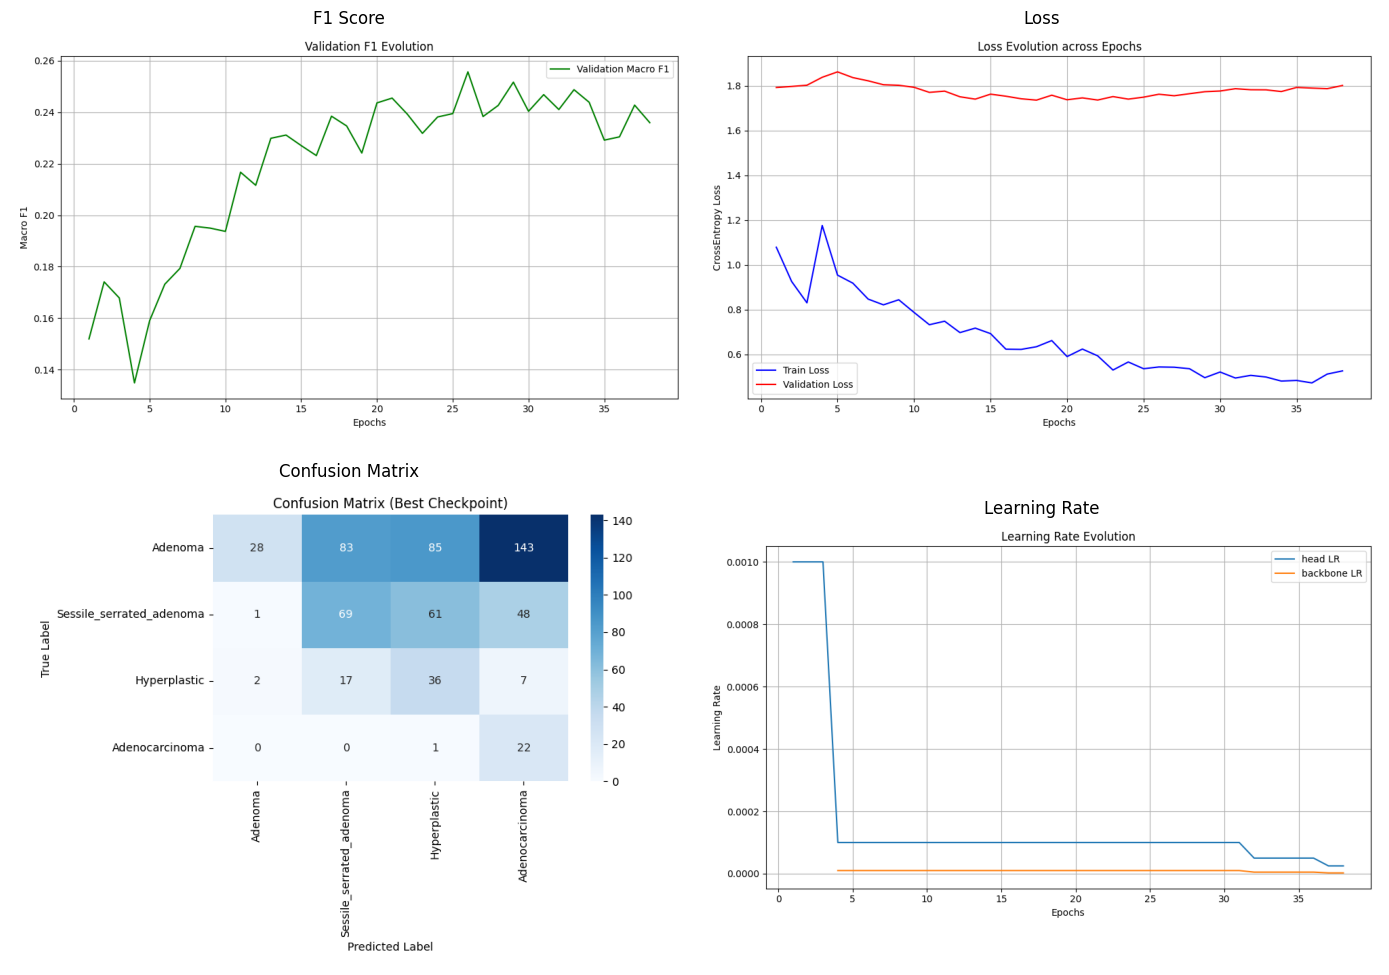

=== GLOBAL METRICS ===
Accuracy:          0.2570
Balanced Accuracy: 0.5013
Macro F1:          0.2557
Weighted F1:       0.2399

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.9032    0.0826    0.1514       339
Sessile_serrated_adenoma     0.4083    0.3855    0.3966       179
            Hyperplastic     0.1967    0.5806    0.2939        62
          Adenocarcinoma     0.1000    0.9565    0.1811        23

                accuracy                         0.2570       603
               macro avg     0.4021    0.5013    0.2557       603
            weighted avg     0.6530    0.2570    0.2399       603



In [6]:
train1.class_weight_exponent = 2.0

baseline_img_dir = Path("unified_images")
baseline_csv_dir = Path("unified_data_baseline.csv")
results_dir = Path("baseline_experiment1_2")

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
best_model_weights_path = results_path / "best_baseline_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not results_path.exists() or not best_model_weights_path.exists():
    trained_model, validation_loader = ModelTrain.train(
        baseline_csv_dir,
        baseline_img_dir,
        results_dir,
        train1,
    )
else:
    print(f"Cargando modelo guardado desde: {best_model_weights_path}")
    trained_model = ModelTrain.PolypClassifier(
        num_classes=len(ModelTrain.CLASS_NAMES),
        dropout=train1.dropout,
        stochastic_depth_prob=train1.stochastic_depth_prob,
    ).to(device)
    trained_model.load_state_dict(
        torch.load(best_model_weights_path, map_location=device)
    )
    trained_model.eval()

    metadata_path = ModelTrain.DATA_DIR / baseline_csv_dir
    train_metadata_df, val_metadata_df = ModelTrain.perform_clinical_data_split(
        metadata_path,
        train_ratio=train1.train_ratio,
        random_state=train1.random_state,
    )
    train_dataset, val_dataset = ModelTrain.build_datasets(
        train_metadata_df,
        val_metadata_df,
        images_dir=ModelTrain.DATA_DIR / baseline_img_dir,
        config=train1,
    )
    _, validation_loader = ModelTrain.build_dataloaders(
        train_dataset,
        val_dataset,
        train_metadata_df=train_metadata_df,
        config=train1,
        device=device,
    )


image_paths = [
    results_path / "f1_score_evolution.png",
    results_path / "loss_evolution.png",
    results_path / "confusion_matrix.png",
    results_path / "learning_rate_evolution.png",
]

titles = [
    "F1 Score",
    "Loss",
    "Confusion Matrix",
    "Learning Rate",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, img_path, title in zip(axes, image_paths, titles):
    img = cv2.imread(str(img_path))

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(
            0.5, 0.5,
            f"Error: {img_path.name} not found",
            fontsize=12,
            color="red",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


device = next(trained_model.parameters()).device
trained_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in validation_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ModelTrain.CLASS_NAMES

accuracy = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("=== GLOBAL METRICS ===")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")


print("\n=== PER-CLASS METRICS ===")
report_text = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report_text)

Cargando modelo guardado desde: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1_15\best_baseline_model.pth


C:\Users\luis\AppData\Local\Temp\ipykernel_19756\163434335.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(best_model_weights_path, map_location=device)


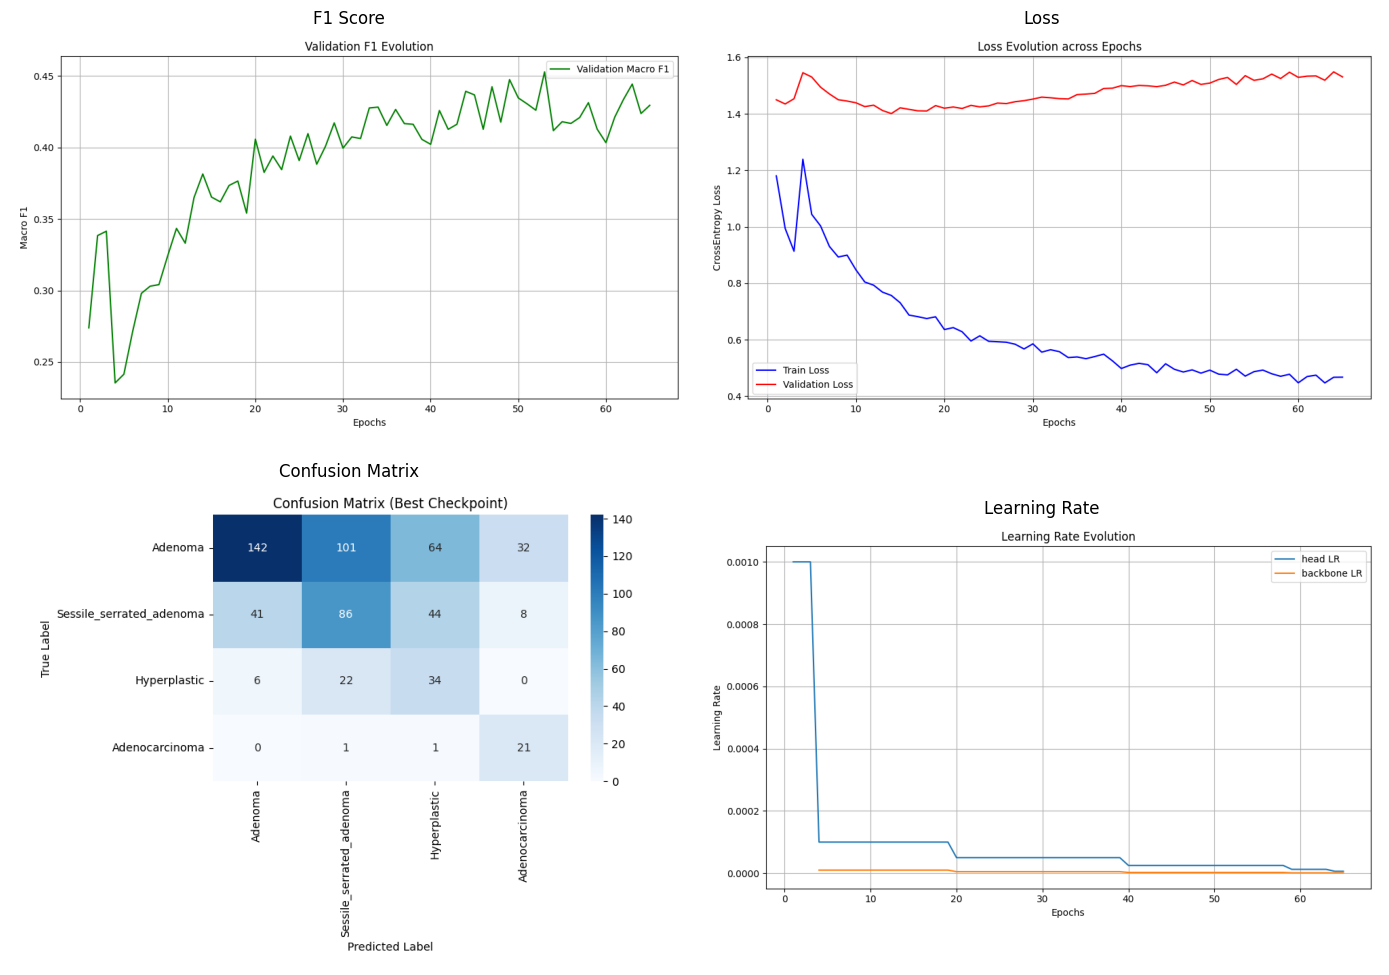

=== GLOBAL METRICS ===
Accuracy:          0.4693
Balanced Accuracy: 0.5902
Macro F1:          0.4529
Weighted F1:       0.4868

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.7513    0.4189    0.5379       339
Sessile_serrated_adenoma     0.4095    0.4804    0.4422       179
            Hyperplastic     0.2378    0.5484    0.3317        62
          Adenocarcinoma     0.3443    0.9130    0.5000        23

                accuracy                         0.4693       603
               macro avg     0.4357    0.5902    0.4529       603
            weighted avg     0.5815    0.4693    0.4868       603



In [7]:
train1.class_weight_exponent = 1.5

baseline_img_dir = Path("unified_images")
baseline_csv_dir = Path("unified_data_baseline.csv")
results_dir = Path("baseline_experiment1_15")

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
best_model_weights_path = results_path / "best_baseline_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not results_path.exists() or not best_model_weights_path.exists():
    trained_model, validation_loader = ModelTrain.train(
        baseline_csv_dir,
        baseline_img_dir,
        results_dir,
        train1,
    )
else:
    print(f"Cargando modelo guardado desde: {best_model_weights_path}")
    trained_model = ModelTrain.PolypClassifier(
        num_classes=len(ModelTrain.CLASS_NAMES),
        dropout=train1.dropout,
        stochastic_depth_prob=train1.stochastic_depth_prob,
    ).to(device)
    trained_model.load_state_dict(
        torch.load(best_model_weights_path, map_location=device)
    )
    trained_model.eval()

    metadata_path = ModelTrain.DATA_DIR / baseline_csv_dir
    train_metadata_df, val_metadata_df = ModelTrain.perform_clinical_data_split(
        metadata_path,
        train_ratio=train1.train_ratio,
        random_state=train1.random_state,
    )
    train_dataset, val_dataset = ModelTrain.build_datasets(
        train_metadata_df,
        val_metadata_df,
        images_dir=ModelTrain.DATA_DIR / baseline_img_dir,
        config=train1,
    )
    _, validation_loader = ModelTrain.build_dataloaders(
        train_dataset,
        val_dataset,
        train_metadata_df=train_metadata_df,
        config=train1,
        device=device,
    )


image_paths = [
    results_path / "f1_score_evolution.png",
    results_path / "loss_evolution.png",
    results_path / "confusion_matrix.png",
    results_path / "learning_rate_evolution.png",
]

titles = [
    "F1 Score",
    "Loss",
    "Confusion Matrix",
    "Learning Rate",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, img_path, title in zip(axes, image_paths, titles):
    img = cv2.imread(str(img_path))

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(
            0.5, 0.5,
            f"Error: {img_path.name} not found",
            fontsize=12,
            color="red",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


device = next(trained_model.parameters()).device
trained_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in validation_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ModelTrain.CLASS_NAMES

accuracy = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("=== GLOBAL METRICS ===")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")


print("\n=== PER-CLASS METRICS ===")
report_text = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report_text)

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1_false_decay


Training Progress:   3%|▎         | 3/100 [02:44<1:28:41, 54.87s/epoch, Stage=head_only, Train Loss=0.9543, Val Loss=1.1098, Val F1=0.4752 [saved], LR=1.0e-03]


Switching to full-network fine-tuning at epoch 4.


Training Progress:  53%|█████▎    | 53/100 [53:54<47:48, 61.03s/epoch, Stage=full_network, Train Loss=0.3649, Val Loss=1.3051, Val F1=0.5469, LR=1.0e-06/6.3e-06]          
c:\Users\luis\Documents\TFG - Data-Centric AI\utils\..\src\ModelTrain.py:920: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't h


Early stopping triggered after 12 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5577 at epoch 42.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1_false_decay'.


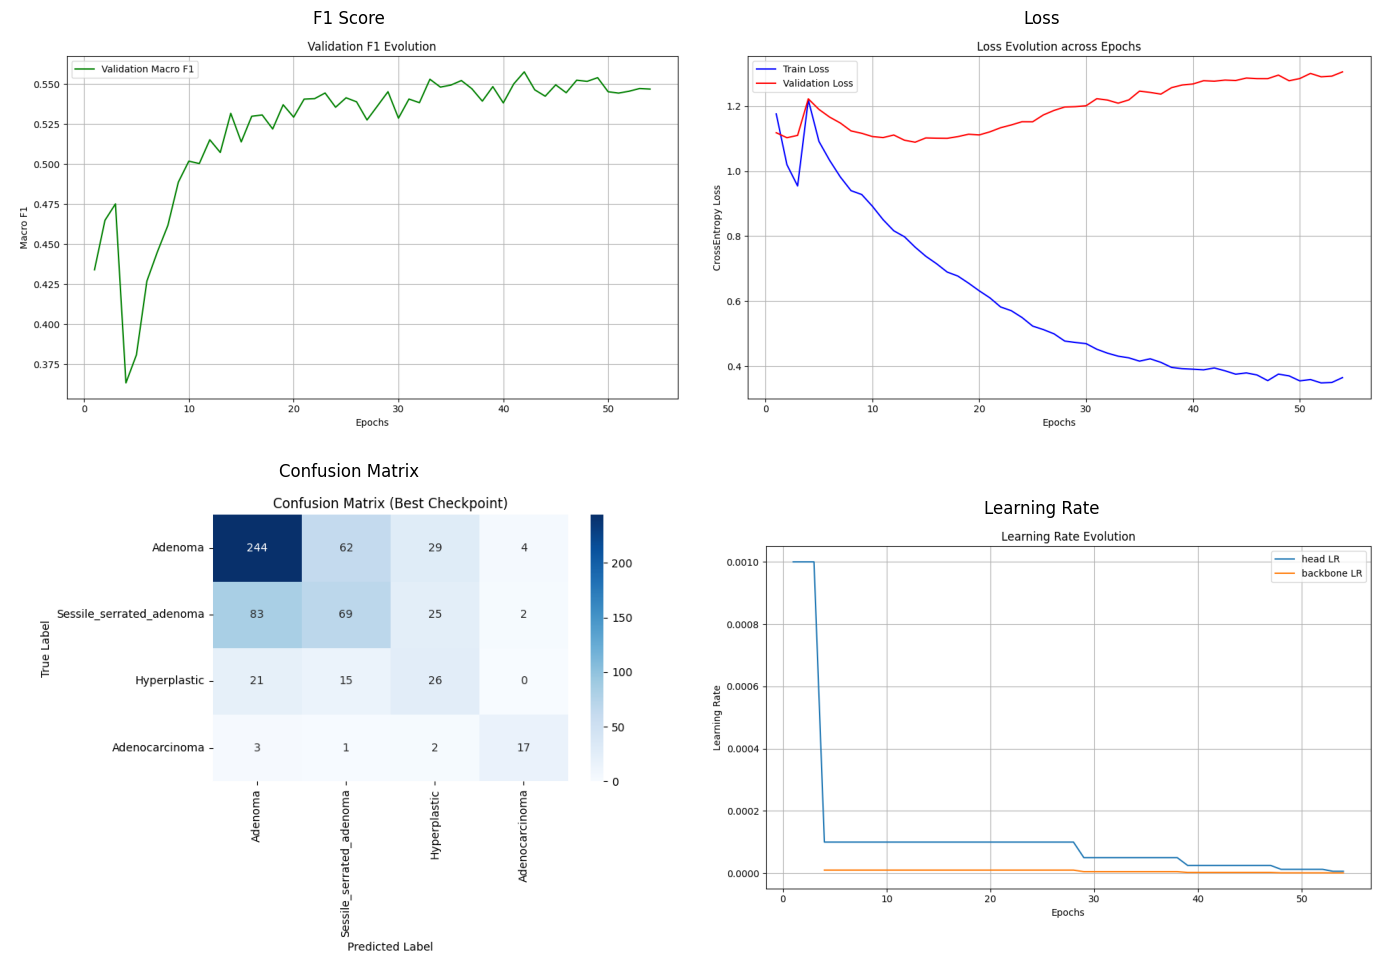

=== GLOBAL METRICS ===
Accuracy:          0.5904
Balanced Accuracy: 0.5659
Macro F1:          0.5577
Weighted F1:       0.5886

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.6952    0.7198    0.7072       339
Sessile_serrated_adenoma     0.4694    0.3855    0.4233       179
            Hyperplastic     0.3171    0.4194    0.3611        62
          Adenocarcinoma     0.7391    0.7391    0.7391        23

                accuracy                         0.5904       603
               macro avg     0.5552    0.5659    0.5577       603
            weighted avg     0.5909    0.5904    0.5886       603



In [9]:
train_old_decay = ModelTrain.TrainingConfig(
    random_state=42,
    warmup_epochs=3,
    scheduler_patience=4,
    early_stopping_patience=12,
    class_weight_exponent=0.5,
    exclude_bn_bias_from_weight_decay=False,
)

baseline_img_dir = Path("unified_images")
baseline_csv_dir = Path("unified_data_baseline.csv")
results_dir = Path("baseline_experiment1_false_decay")

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
best_model_weights_path = results_path / "best_baseline_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not results_path.exists() or not best_model_weights_path.exists():
    trained_model, validation_loader = ModelTrain.train(
        baseline_csv_dir,
        baseline_img_dir,
        results_dir,
        train_old_decay,
    )
else:
    print(f"Cargando modelo guardado desde: {best_model_weights_path}")
    trained_model = ModelTrain.PolypClassifier(
        num_classes=len(ModelTrain.CLASS_NAMES),
        dropout=train_old_decay.dropout,
        stochastic_depth_prob=train_old_decay.stochastic_depth_prob,
    ).to(device)
    trained_model.load_state_dict(
        torch.load(best_model_weights_path, map_location=device)
    )
    trained_model.eval()

    metadata_path = ModelTrain.DATA_DIR / baseline_csv_dir
    train_metadata_df, val_metadata_df = ModelTrain.perform_clinical_data_split(
        metadata_path,
        train_ratio=train_old_decay.train_ratio,
        random_state=train_old_decay.random_state,
    )
    train_dataset, val_dataset = ModelTrain.build_datasets(
        train_metadata_df,
        val_metadata_df,
        images_dir=ModelTrain.DATA_DIR / baseline_img_dir,
        config=train_old_decay,
    )
    _, validation_loader = ModelTrain.build_dataloaders(
        train_dataset,
        val_dataset,
        train_metadata_df=train_metadata_df,
        config=train_old_decay,
        device=device,
    )


image_paths = [
    results_path / "f1_score_evolution.png",
    results_path / "loss_evolution.png",
    results_path / "confusion_matrix.png",
    results_path / "learning_rate_evolution.png",
]

titles = [
    "F1 Score",
    "Loss",
    "Confusion Matrix",
    "Learning Rate",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, img_path, title in zip(axes, image_paths, titles):
    img = cv2.imread(str(img_path))

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(
            0.5, 0.5,
            f"Error: {img_path.name} not found",
            fontsize=12,
            color="red",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


device = next(trained_model.parameters()).device
trained_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in validation_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ModelTrain.CLASS_NAMES

accuracy = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("=== GLOBAL METRICS ===")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")


print("\n=== PER-CLASS METRICS ===")
report_text = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report_text)

Hardware assigned for tensor computations: cuda
Train class distribution:
histology
Adenoma                     1555
Sessile_serrated_adenoma     660
Hyperplastic                 337
Adenocarcinoma                97

Validation class distribution:
histology
Adenoma                     339
Sessile_serrated_adenoma    179
Hyperplastic                 62
Adenocarcinoma               23

Loss weights: {'Adenoma': 0.4605, 'Sessile_serrated_adenoma': 0.7068, 'Hyperplastic': 0.9891, 'Adenocarcinoma': 1.8436}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1_true_decay


Training Progress:   3%|▎         | 3/100 [02:43<1:27:57, 54.41s/epoch, Stage=head_only, Train Loss=0.9543, Val Loss=1.1098, Val F1=0.4752 [saved], LR=1.0e-03/1.0e-03]


Switching to full-network fine-tuning at epoch 4.


Training Progress:  53%|█████▎    | 53/100 [53:34<47:30, 60.65s/epoch, Stage=full_network, Train Loss=0.3649, Val Loss=1.3052, Val F1=0.5469, LR=1.0e-06/1.0e-06/6.3e-06/6.3e-06]          
c:\Users\luis\Documents\TFG - Data-Centric AI\utils\..\src\ModelTrain.py:920: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case w


Early stopping triggered after 12 epochs without improving macro-F1.

Optimization sequence completed. Best validation macro-F1: 0.5577 at epoch 42.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment1_true_decay'.


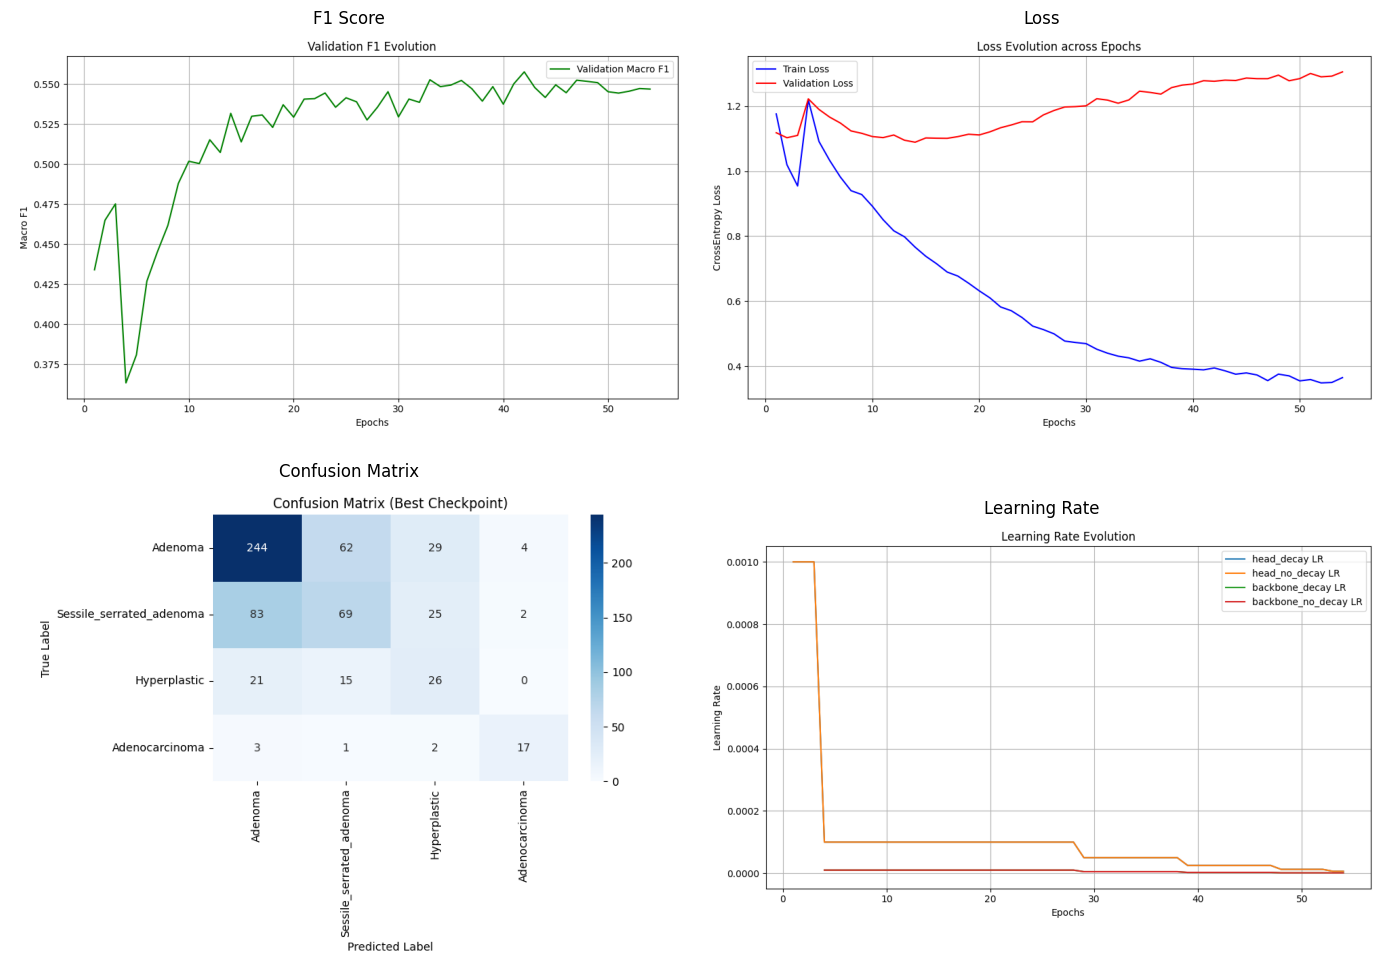

=== GLOBAL METRICS ===
Accuracy:          0.5904
Balanced Accuracy: 0.5659
Macro F1:          0.5577
Weighted F1:       0.5886

=== PER-CLASS METRICS ===
                          precision    recall  f1-score   support

                 Adenoma     0.6952    0.7198    0.7072       339
Sessile_serrated_adenoma     0.4694    0.3855    0.4233       179
            Hyperplastic     0.3171    0.4194    0.3611        62
          Adenocarcinoma     0.7391    0.7391    0.7391        23

                accuracy                         0.5904       603
               macro avg     0.5552    0.5659    0.5577       603
            weighted avg     0.5909    0.5904    0.5886       603



In [10]:
train_clean_decay = ModelTrain.TrainingConfig(
    random_state=42,
    warmup_epochs=3,
    scheduler_patience=4,
    early_stopping_patience=12,
    class_weight_exponent=0.5,
    exclude_bn_bias_from_weight_decay=True,
)

baseline_img_dir = Path("unified_images")
baseline_csv_dir = Path("unified_data_baseline.csv")
results_dir = Path("baseline_experiment1_true_decay")

results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
best_model_weights_path = results_path / "best_baseline_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not results_path.exists() or not best_model_weights_path.exists():
    trained_model, validation_loader = ModelTrain.train(
        baseline_csv_dir,
        baseline_img_dir,
        results_dir,
        train_clean_decay,
    )
else:
    print(f"Cargando modelo guardado desde: {best_model_weights_path}")
    trained_model = ModelTrain.PolypClassifier(
        num_classes=len(ModelTrain.CLASS_NAMES),
        dropout=train_clean_decay.dropout,
        stochastic_depth_prob=train_clean_decay.stochastic_depth_prob,
    ).to(device)
    trained_model.load_state_dict(
        torch.load(best_model_weights_path, map_location=device)
    )
    trained_model.eval()

    metadata_path = ModelTrain.DATA_DIR / baseline_csv_dir
    train_metadata_df, val_metadata_df = ModelTrain.perform_clinical_data_split(
        metadata_path,
        train_ratio=train_clean_decay.train_ratio,
        random_state=train_clean_decay.random_state,
    )
    train_dataset, val_dataset = ModelTrain.build_datasets(
        train_metadata_df,
        val_metadata_df,
        images_dir=ModelTrain.DATA_DIR / baseline_img_dir,
        config=train_clean_decay,
    )
    _, validation_loader = ModelTrain.build_dataloaders(
        train_dataset,
        val_dataset,
        train_metadata_df=train_metadata_df,
        config=train_clean_decay,
        device=device,
    )


image_paths = [
    results_path / "f1_score_evolution.png",
    results_path / "loss_evolution.png",
    results_path / "confusion_matrix.png",
    results_path / "learning_rate_evolution.png",
]

titles = [
    "F1 Score",
    "Loss",
    "Confusion Matrix",
    "Learning Rate",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, img_path, title in zip(axes, image_paths, titles):
    img = cv2.imread(str(img_path))

    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(
            0.5, 0.5,
            f"Error: {img_path.name} not found",
            fontsize=12,
            color="red",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


device = next(trained_model.parameters()).device
trained_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in validation_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = ModelTrain.CLASS_NAMES

accuracy = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("=== GLOBAL METRICS ===")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")


print("\n=== PER-CLASS METRICS ===")
report_text = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report_text)